In [1]:
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import seaborn as sns
import matplotlib.colors as mcolors
import getdist.plots

In [2]:
# get header from chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt

# load header of ("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt"
# the header is the lines that start with '#'
header = []
with open("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 'r') as f:
    # only read the top lines until it doesn't start with '#'
    for line in f:
        if line.startswith('#'):
            header.append(line.strip()[3:])
        else:
            break
    

# from header, extract the parameter names and values, which are after 'Parameter values and priors:'
parameter_values = {}
parameter_names = []
flag_params = False
for item in header:
    if flag_params:
        # split by comma, then by '='
        params = item.split(',')
        for param in params:
            name, value = param.split('=')
            name = name.strip()
            value = float(value.strip())
            parameter_values[name] = value
            parameter_names.append(name)
        flag_params = False
    if item.startswith(' Parameter values and priors:'):
        flag_params = True
        continue
    

print(parameter_names)
print(parameter_values)

cosmo_universe = ccl.Cosmology(Omega_c=parameter_values['Omega_m'] - parameter_values['Omega_b'], Omega_b=parameter_values['Omega_b'], 
                               h=parameter_values['h'], A_s=parameter_values['A_s'], n_s=parameter_values['n_s'])

f_phi_universe = parameter_values['f_phi']
Bias_distribution_fiducial = np.array([parameter_values['b1'], parameter_values['b2'], parameter_values['b3'], parameter_values['b4'], parameter_values['b5']])

['Omega_m', 'f_phi', 'A_s', 'h', 'n_s', 'Omega_b', 'b1', 'b2', 'b3', 'b4', 'b5']
{'Omega_m': 0.3137721, 'f_phi': 1.0, 'A_s': 2.056248707e-09, 'h': 0.6736, 'n_s': 0.9649, 'Omega_b': 0.0493017, 'b1': 1.562362, 'b2': 1.732963, 'b3': 1.913252, 'b4': 2.100644, 'b5': 2.29321}


In [3]:
labels = parameter_names

#["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
fiducials = [cosmo_universe["Omega_m"], f_phi_universe, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"],\
         Bias_distribution_fiducial[0], Bias_distribution_fiducial[1],\
         Bias_distribution_fiducial[2],Bias_distribution_fiducial[3],\
         Bias_distribution_fiducial[4]]


Removed no burn in


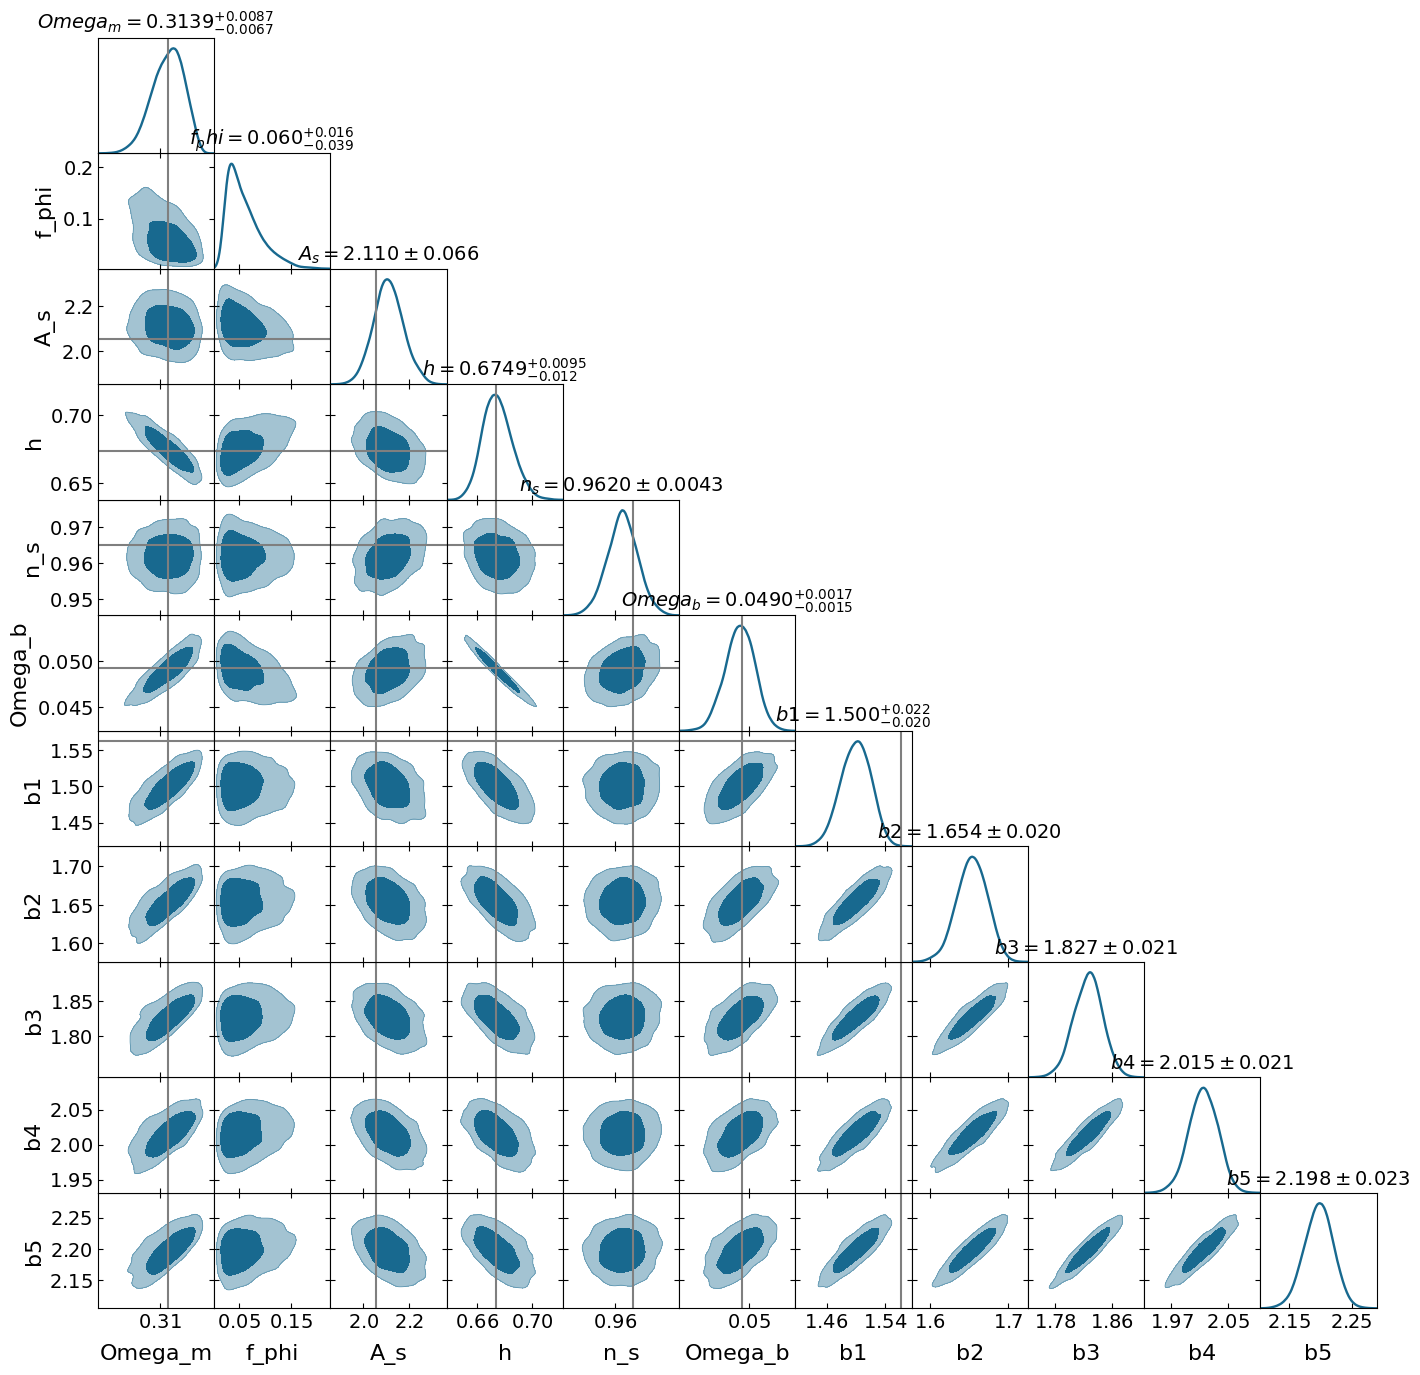

In [7]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.txt"]
samples = []
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names, weights=np.exp(data[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})
    )
    
    colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
    g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

    plt.rcParams.update({'font.size':16})
    g.settings.legend_fontsize=20
    g.settings.axes_fontsize=18
    g.settings.axes_labelsize=20
    g.settings.linewidth=4   
    g.settings.figure_legend_frame = False

    g.triangle_plot(samples,
        parameter_names,
        title_limit=1,  # first title limit (for 1D plots) is 68% by default
        legend_loc = 'upper right',
        contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':False, 'color': colors[3], 'ls': '--'}], 
        line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '--'}])
    
    # plot fiducial values as gray lines
    for i in range(len(parameter_names)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            if i != j and parameter_names[i] in parameter_values and fiducials[i] != None:
                ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
            if parameter_names[j] in parameter_values and fiducials[j] != None:
                ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    

### Figure out if priors are an issue

In [61]:
#### Get Planck priors #####
import yaml
from nautilus import Prior, Sampler


config_file = "/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/ini_files/config_run_ell1500_k0p2_Nbody.yaml"
# read the config file
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)


sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

with open(config['data']['params'], 'r') as f:
        params = yaml.safe_load(f)

# add additional bespoke priors if needed
def log_prior(theta_dict):
    theta = [float(theta_dict[key]) for key in ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]]
    Omega_c, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5 = theta 
    priors = params['priors']
    if not priors['Planck_prior']:
        return 0.0
    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
    
    return gauss_funct.logpdf([n_s, Omega_b*h**2])

# add standard priors
prior = Prior()
params_list = ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
for par_i in params_list:
    prior.add_parameter(par_i, dist=(params['priors'][par_i][0], params['priors'][par_i][1]))


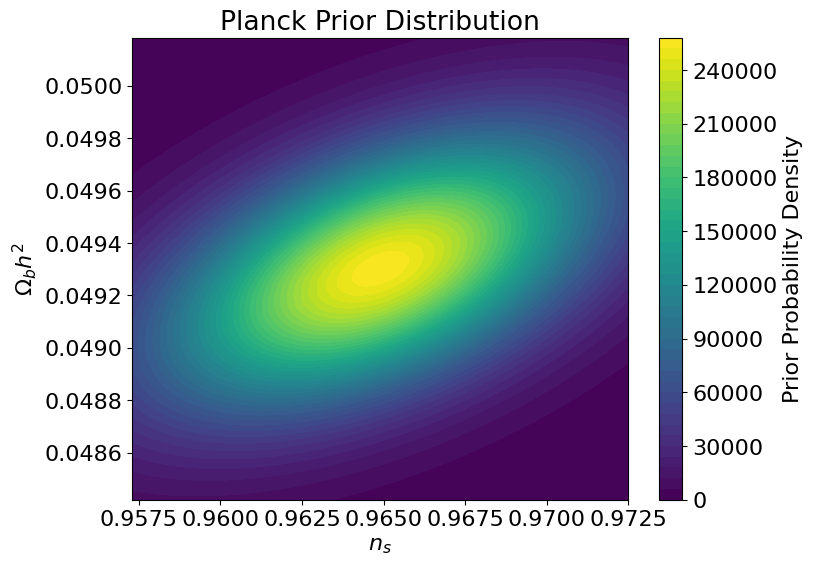

In [69]:
# plot prior distribution for n_s and Omega_b*h^2
import scipy


n_s_range = np.linspace(cosmo_universe['n_s']-0.0038*2, cosmo_universe['n_s']+0.0038*2, 100)
Omega_b_h2_range = np.linspace(cosmo_universe['Omega_b']*cosmo_universe["h"]**2-0.0002*2, cosmo_universe['Omega_b']*cosmo_universe["h"]**2+0.0002*2, 100)
n_s_grid, Omega_b_h2_grid = np.meshgrid(n_s_range, Omega_b_h2_range)
pos = np.dstack((n_s_grid, Omega_b_h2_grid))

prior_val = np.zeros_like(n_s_grid)
for i in range(n_s_grid.shape[0]):
    for j in range(n_s_grid.shape[1]):
        prior_val[i,j] = log_prior({"Omega_m": cosmo_universe["Omega_m"], "f_phi": f_phi_universe, "1e9As": cosmo_universe["A_s"]*1e9, "h": cosmo_universe["h"], "ns": n_s_grid[i,j], "Omega_b": Omega_b_h2_grid[i,j]/cosmo_universe["h"]**2, "b1": Bias_distribution_fiducial[0], "b2": Bias_distribution_fiducial[1], "b3": Bias_distribution_fiducial[2], "b4": Bias_distribution_fiducial[3], "b5": Bias_distribution_fiducial[4]})

plt.figure(figsize=(8,6))
plt.contourf(n_s_grid, Omega_b_h2_grid/cosmo_universe["h"]**2, np.exp(prior_val), levels=50, cmap='viridis')
plt.colorbar(label='Prior Probability Density')
plt.xlabel(r'$n_s$')
plt.ylabel(r'$\Omega_b h^2$')
plt.title('Planck Prior Distribution')
plt.show()


